In [54]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

Cargar datos

Cargamos y procesamos los datos del Inventario de Depresión de Beck (BDI-II), asignando niveles de depresión según el puntaje total. Las características y etiquetas se separaron, y las etiquetas fueron codificadas numéricamente. Las características fueron normalizadas con StandardScaler y los datos se dividieron en conjuntos de entrenamiento y prueba (80%-20%). Finalmente, los datos fueron convertidos a tensores de PyTorch para ser utilizados en el entrenamiento del modelo.

In [55]:
# Cargar el archivo CSV
datos_df = pd.read_csv('DATOS.csv')

# Lógica clínica del BDI-II
def asignar_nivel_depresion(total):
    if 0 <= total <= 13:
        return 'Ninguna depresión'
    elif 14 <= total <= 19:
        return 'Depresión leve'
    elif 20 <= total <= 28:
        return 'Depresión moderada'
    elif 29 <= total <= 63:
        return 'Depresión grave'
    else:
        return 'Valor fuera de rango'

datos_df['Nivel_Depresión'] = datos_df['TOTAL'].apply(asignar_nivel_depresion)

# Características y etiquetas
X = datos_df.drop(['id', 'Nivel_Depresión', 'TOTAL'], axis=1)
y = datos_df['Nivel_Depresión']

# Codificar las etiquetas
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Normalizar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Convertir a tensores de PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


Creamos un Dataset personalizado para gestionar los datos de entrada y sus etiquetas. A continuación, definimos DataLoaders para cargar los datos de entrenamiento y validación, lo que facilita el manejo del tamaño de los lotes y el orden de los datos durante el entrenamiento, optimizando el proceso de ajuste del modelo.

In [56]:
# Definir el Dataset para PyTorch
class DepressionDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Crear los DataLoaders para el entrenamiento y validación
train_dataset = DepressionDataset(X_train_tensor, y_train_tensor)
val_dataset = DepressionDataset(X_test_tensor, y_test_tensor)

dataset = {
    'train': train_dataset,
    'val': val_dataset,
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False),
}

Entrenamos un modelo de Perceptrón Multicapa (MLP) para clasificar los niveles de depresión, con una capa oculta de 100 neuronas y 4 clases de salida. Usamos el optimizador Adam y CrossEntropyLoss. La función fit entrenó el modelo durante 400 épocas, guardando el mejor basado en el rendimiento del conjunto de validación.

In [57]:
def softmax(x):
    return torch.softmax(x, dim=-1)

class MLPModel(nn.Module):
    def __init__(self, D_in, H, D_out):
        super(MLPModel, self).__init__()
        self.model = nn.Sequential(
        # 1. Capa de Entrada (D_in -> H) - La "primera capa oculta"
        torch.nn.Linear(D_in, H),
        # Activación
        torch.nn.ReLU(),
        # 2. Capa de Salida (H -> D_out)
        torch.nn.Linear(H, D_out)
        )

    def forward(self, x):
        return self.model(x)


def fit(model, dataloader, optimizer, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}


model = MLPModel(D_in=X_train.shape[1], H=100, D_out=4)  # Ajuste para tu conjunto de datos
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist_adam = fit(model, dataloader, optimizer, epochs=400, log_each=10, early_stopping=10)


Mejor modelo guardado con acc 0.90350 en epoch 1
Mejor modelo guardado con acc 0.95250 en epoch 2
Mejor modelo guardado con acc 0.95950 en epoch 3
Mejor modelo guardado con acc 0.97100 en epoch 4
Mejor modelo guardado con acc 0.97750 en epoch 5
Mejor modelo guardado con acc 0.98200 en epoch 6
Mejor modelo guardado con acc 0.98350 en epoch 10
Epoch 10/400 loss 0.04693 acc 0.98875 val_loss 0.05413 val_acc 0.98350
Mejor modelo guardado con acc 0.98750 en epoch 11
Mejor modelo guardado con acc 0.98900 en epoch 18
Epoch 20/400 loss 0.02067 acc 0.99513 val_loss 0.03117 val_acc 0.98700
Mejor modelo guardado con acc 0.99050 en epoch 22
Epoch 30/400 loss 0.01134 acc 0.99862 val_loss 0.03016 val_acc 0.98500
Entrenamiento detenido en epoch 32 por no mejorar en 10 epochs seguidas


EVALUACION FINAL

Finalmente evaluamos el modelo en el conjunto de prueba y generamos un reporte de clasificación con precisión, recall y F1-score.

In [58]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    _, predicted = torch.max(y_pred, 1)
    print("\nReporte de clasificación:")
    print(classification_report(y_test_tensor.numpy(), predicted.numpy()))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1092
           1       0.96      0.88      0.92       122
           2       0.99      1.00      0.99       581
           3       0.97      0.99      0.98       205

    accuracy                           0.99      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.99      0.99      0.99      2000



GRAFICAMOS

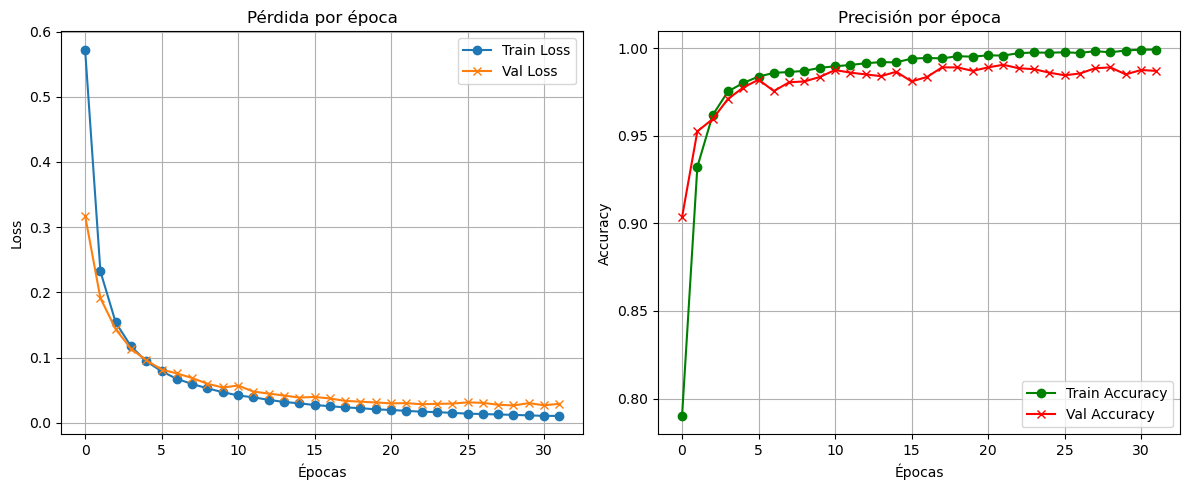

In [59]:
# Graficar resultados
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_adam['loss'], marker='o', label='Train Loss')
plt.plot(hist_adam['val_loss'], marker='x', label='Val Loss')
plt.title("Pérdida por época")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_adam['acc'], marker='o', label='Train Accuracy', color='green')
plt.plot(hist_adam['val_acc'], marker='x', label='Val Accuracy', color='red')
plt.title("Precisión por época")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

GUARDAMOS

In [60]:
import joblib
import torch

# Guardar el modelo entrenado de PyTorch
torch.save(model.state_dict(), 'mlp_model.pth')

# Guardar el escalador (scaler)
joblib.dump(scaler, 'scaler.pkl')

# Guardar el encoder
joblib.dump(encoder, 'encoder.pkl')

print("Modelo, escalador y encoder guardados.")


Modelo, escalador y encoder guardados.


In [62]:
import torch

# Suponiendo que tienes un nuevo conjunto de respuestas en un formulario (formulario_depresion)
# Aquí un ejemplo con valores ficticios para las respuestas:
nuevo_usuario_respuestas = [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]] 

# Escalar las respuestas nuevas usando el mismo escalador
nuevo_usuario_respuestas_scaled = scaler.transform(nuevo_usuario_respuestas)

# Convertir a tensor de PyTorch
nuevo_usuario_respuestas_tensor = torch.tensor(nuevo_usuario_respuestas_scaled, dtype=torch.float32)

# Realizar la predicción con el modelo (asegúrate de que el modelo esté en modo de evaluación)
model.eval()
with torch.no_grad():
    predicciones = model(nuevo_usuario_respuestas_tensor)

# Convertir las predicciones a etiquetas (usando softmax y luego argmax)
_, prediccion_max = torch.max(predicciones, dim=1)

# Decodificar la predicción (convertir el número a la etiqueta de depresión)
nivel_depresion = encoder.inverse_transform(prediccion_max.cpu().numpy())

print(f"El nivel de depresión predicho es: {nivel_depresion[0]}")


El nivel de depresión predicho es: Depresión leve


c:\ProgramData\anaconda3\envs\IA\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
